# Laboratory 4: Making Your Own Image Filters

## Overview
This laboratory is about building image tools from scratch rather than just using pre-made ones. We will learn how to turn a color picture into black and white manually, how to blur an image to remove "noise" (random dots), and how to find the edges of objects using a method called Sobel Edge Detection.

## Topics Used
* **Manual Grayscale:** Turning a color image into black and white by averaging the Colors (Red, Green, Blue).
* **Custom 2D Convolution:** Moving a small grid of numbers (a kernel) across the image to change how it looks.
* **Blur Kernels (Denoising):** Using a specific grid of numbers to smooth out the image.
* **Sobel Edge Detection:** Using math to find where the colors change quickly, which tells us where the edges are.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# This helper function lets us show images in our notebook
def show_image(img, title='Image'):
    plt.figure(figsize=(8, 6))
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

### Step 1: Loading the image
We start with a picture of a cat that has some blurry parts.

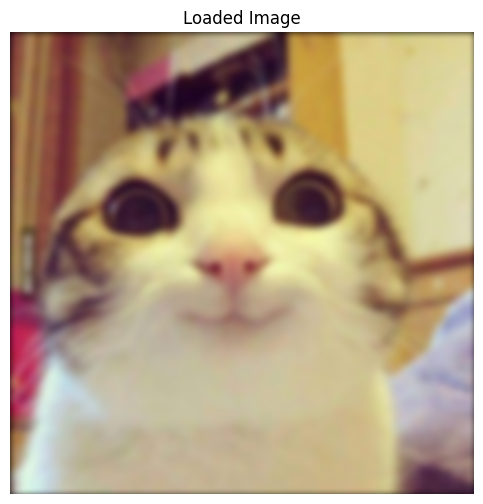

In [2]:
img = cv2.imread('cat_blur.png')
height = img.shape[0]
width = img.shape[1]
gray = np.zeros((height, width), dtype=np.uint8)
show_image(img, 'Loaded Image')

### Step 2: Custom Grayscale Conversion
Instead of using a command, we loop through every single pixel and calculate the gray value ourselves!

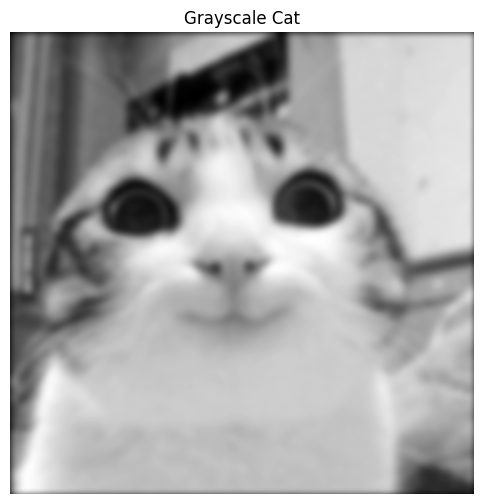

In [3]:
for i in range(height):
    for j in range(width):
        # Get the color values for this pixel
        b = img[i, j, 0]
        g = img[i, j, 1]
        r = img[i, j, 2]

        # Scientists found this formula works best for human eyes
        gray_val = 0.299 * r + 0.587 * g + 0.114 * b
        gray[i, j] = int(gray_val)

show_image(gray, 'Grayscale Cat')

### Step 3: The Filter Function (Convolution)
This is the heart of image filtering. We take a 3x3 grid (the kernel), put it over a pixel and its neighbors, multiply the numbers, and add them up. This new number becomes the new pixel value.

In [4]:
def apply_filter(image, kernel):
    img_h, img_w = image.shape
    # We go through the image, but skip the very edges to avoid errors
    output = np.zeros((img_h, img_w), dtype=np.float32)

    for i in range(1, img_h - 1):
        for j in range(1, img_w - 1):
            sum_val = 0
            # Look at the 3x3 neighborhood
            for ki in range(3):
                for kj in range(3):
                    pixel = image[i + ki - 1, j + kj - 1]
                    kernel_val = kernel[ki, kj]
                    sum_val += pixel * kernel_val
            output[i, j] = sum_val
    return output

### Step 4: Blurring and Setup Sobel Kernels
A blur kernel is just an average of the surrounding pixels. The Sobel kernels are special grids designed to find horizontal and vertical lines.

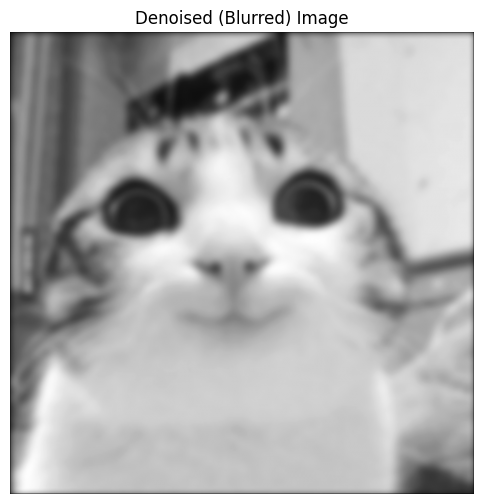

In [5]:
# This kernel averages 9 pixels equally to create blur
blur_kernel = [ [1/9, 1/9, 1/9], [1/9, 1/9, 1/9], [1/9, 1/9, 1/9] ]
denoised = apply_filter(gray, np.array(blur_kernel))

# Sobel X finds vertical lines, Sobel Y finds horizontal lines
sobel_x = np.array([[-1, 0, 1],  [-2, 0, 2],  [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1],  [ 0,  0,  0],  [ 1,  2,  1]])

show_image(denoised.astype(np.uint8), 'Denoised (Blurred) Image')

### Step 5: Finding the Edges
We apply our Sobel filters, then combine them to get the "final mapping" of all edges.

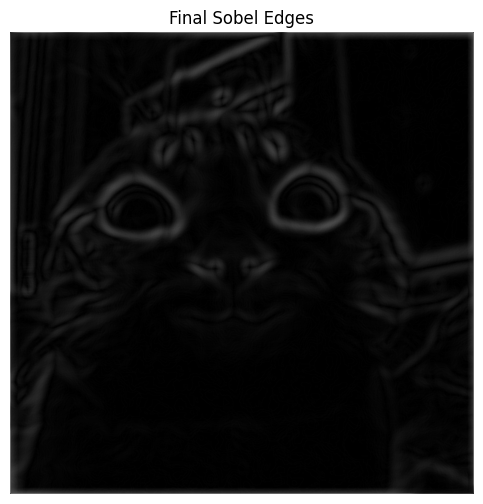

In [6]:
grad_x = apply_filter(denoised, sobel_x)
grad_y = apply_filter(denoised, sobel_y)

final_edges = np.zeros((height, width), dtype=np.uint8)
for i in range(height):
    for j in range(width):
        # Combine the vertical and horizontal edges
        val = abs(grad_x[i, j]) + abs(grad_y[i, j])
        if val > 255: val = 255
        final_edges[i, j] = int(val)

show_image(final_edges, 'Final Sobel Edges')

### Step 6: Saving the Result
We save our hard work as a new image!

In [7]:
cv2.imwrite('output.png', final_edges)
print("Done! Check output.png for the vibes ✨")

Done! Check output.png for the vibes ✨
